# Feature Engineering & Preprocessing for Recommendation System

This notebook prepares features for the recommendation algorithm by normalizing, standardizing, and creating feature vectors.

## Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style("whitegrid")

## Load Cleaned Dataset

In [2]:
# Load cleaned data
data_path = Path('../data')
df = pd.read_csv(data_path / 'cleaned_spotify.csv')

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst few rows:")
df.head()

Dataset loaded successfully!
Shape: (586601, 20)

Columns: ['id', 'name', 'popularity', 'duration_ms', 'explicit', 'artists', 'id_artists', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'release_year']

First few rows:


,id,name,popularity,duration_ms,explicit,artists,id_artists,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,release_year
0,35iwgR4jXetI318WEWsa1Q,Carve,6,126903,False,['Uli'],['45tIt06XoI0Iio4LBEVpls'],0.645,0.4450,0,-13.338,True,0.4510,0.674,0.7440,0.151,0.127,104.851,3,1922
1,021ht4sdgPcrDgSk7JTbKY,Capítulo 2.16 - Banquero Anarquista,0,98200,False,['Fernando Pessoa'],['14jtPCOoNZwquk5wd9DxrY'],0.695,0.2630,0,-22.136,True,0.9570,0.797,0.0000,0.148,0.655,102.009,1,1922
2,07A5yehtSnoedViJAZkNnc,Vivo para Quererte - Remasterizado,0,181640,False,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],0.434,0.1770,1,-21.180,True,0.0512,0.994,0.0218,0.212,0.457,130.418,5,1922
3,08FmqUhxtyLTn6pAh6bk45,El Prisionero - Remasterizado,0,176907,False,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],0.321,0.0946,7,-27.961,True,0.0504,0.995,0.9180,0.104,0.397,169.980,3,1922
4,08y9GfoqCWfOGsKdwojr5e,Lady of the Evening,0,163080,False,['Dick Haymes'],['3BiJGZsyX9sJchTqcSA7Su'],0.402,0.1580,3,-16.900,False,0.0390,0.989,0.1300,0.311,0.196,103.220,4,1922


## Identify Feature Types

In [3]:
# Define feature categories
audio_features = ['danceability', 'energy', 'speechiness', 'acousticness',
                  'instrumentalness', 'liveness', 'valence']

numerical_features = ['loudness', 'tempo', 'duration_ms', 'popularity', 'release_year']

# Verify all features exist
print("Audio Features (0-1 range):")
for feat in audio_features:
    if feat in df.columns:
        print(f"  ✓ {feat}: min={df[feat].min():.3f}, max={df[feat].max():.3f}, mean={df[feat].mean():.3f}")

print("\nNumerical Features (need scaling):")
for feat in numerical_features:
    if feat in df.columns:
        print(f"  ✓ {feat}: min={df[feat].min():.2f}, max={df[feat].max():.2f}, mean={df[feat].mean():.2f}")

Audio Features (0-1 range):
  ✓ danceability: min=0.000, max=0.991, mean=0.564
  ✓ energy: min=0.000, max=1.000, mean=0.542
  ✓ speechiness: min=0.000, max=0.971, mean=0.105
  ✓ acousticness: min=0.000, max=0.996, mean=0.450
  ✓ instrumentalness: min=0.000, max=1.000, mean=0.113
  ✓ liveness: min=0.000, max=1.000, mean=0.214
  ✓ valence: min=0.000, max=1.000, mean=0.552

Numerical Features (need scaling):
  ✓ loudness: min=-60.00, max=5.38, mean=-10.21
  ✓ tempo: min=0.00, max=246.38, mean=118.47
  ✓ duration_ms: min=3344.00, max=5621218.00, mean=230054.85
  ✓ popularity: min=0.00, max=100.00, mean=27.57
  ✓ release_year: min=1900.00, max=2021.00, mean=1988.57


## Handle Outliers (Optional but Recommended)

In [4]:
# Function to detect and handle outliers using IQR method
def handle_outliers(data, column, method='clip'):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers_count = ((data[column] < lower_bound) | (data[column] > upper_bound)).sum()
    
    if method == 'clip':
        data[column] = data[column].clip(lower_bound, upper_bound)
    
    return outliers_count, lower_bound, upper_bound

# Apply to features that might have outliers
outlier_candidates = ['loudness', 'tempo', 'duration_ms']
df_processed = df.copy()

print("Handling Outliers:")
for feat in outlier_candidates:
    if feat in df_processed.columns:
        count, lower, upper = handle_outliers(df_processed, feat)
        print(f"  • {feat}: {count} outliers clipped (bounds: {lower:.2f} - {upper:.2f})")

print("\n✓ Outliers handled")

Handling Outliers:
  • loudness: 15097 outliers clipped (bounds: -22.51 - 3.13)
  • tempo: 5709 outliers clipped (bounds: 34.53 - 197.40)
  • duration_ms: 27179 outliers clipped (bounds: 41907.00 - 397043.00)

✓ Outliers handled


## Feature Selection: Drop Redundant Features

In [5]:
# From EDA, energy and loudness are highly correlated (~0.7+)
# Keep energy (more commonly used), drop loudness

print("Feature Selection:")
print("  • Energy and Loudness correlation: ~0.75 (highly correlated)")
print("  • Decision: KEEP 'energy', DROP 'loudness' (redundant)")
print("  • Reason: Energy is more psychoacoustic, loudness is more physical")

# Drop loudness
df_processed = df_processed.drop(columns=['loudness'])

print("\n✓ Redundant features removed")
print(f"\nRemaining features: {list(df_processed.columns)[:20]}...") # Show first 20

Feature Selection:
  • Energy and Loudness correlation: ~0.75 (highly correlated)
  • Decision: KEEP 'energy', DROP 'loudness' (redundant)
  • Reason: Energy is more psychoacoustic, loudness is more physical

✓ Redundant features removed

Remaining features: ['id', 'name', 'popularity', 'duration_ms', 'explicit', 'artists', 'id_artists', 'danceability', 'energy', 'key', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'release_year']...


## Normalize Audio Features (Already 0-1, Just Verify)

In [6]:
# Audio features should already be 0-1, verify and normalize if needed
print("Verifying Audio Features (should be 0-1):")

for feat in audio_features:
    if feat in df_processed.columns:
        min_val = df_processed[feat].min()
        max_val = df_processed[feat].max()
        in_range = (min_val >= 0) and (max_val <= 1)
        status = "✓" if in_range else "⚠"
        print(f"  {status} {feat}: [{min_val:.4f}, {max_val:.4f}]")

print("\n✓ Audio features already normalized")

Verifying Audio Features (should be 0-1):
  ✓ danceability: [0.0000, 0.9910]
  ✓ energy: [0.0000, 1.0000]
  ✓ speechiness: [0.0000, 0.9710]
  ✓ acousticness: [0.0000, 0.9960]
  ✓ instrumentalness: [0.0000, 1.0000]
  ✓ liveness: [0.0000, 1.0000]
  ✓ valence: [0.0000, 1.0000]

✓ Audio features already normalized


## Standardize Numerical Features

In [7]:
# Features to standardize
features_to_scale = ['tempo', 'duration_ms', 'popularity', 'release_year']

# Check which exist
features_to_scale = [f for f in features_to_scale if f in df_processed.columns]

print(f"Features to standardize: {features_to_scale}")
print("\nBefore scaling:")
print(df_processed[features_to_scale].describe())

# Use StandardScaler (mean=0, std=1) for better ML compatibility
scaler = StandardScaler()
df_scaled_temp = df_processed[features_to_scale].copy()
df_scaled_temp[features_to_scale] = scaler.fit_transform(df_processed[features_to_scale])

print("\nAfter scaling:")
print(df_scaled_temp.describe())

# Update original dataframe
df_processed[features_to_scale] = df_scaled_temp[features_to_scale]

print("\n✓ Features standardized")

Features to standardize: ['tempo', 'duration_ms', 'popularity', 'release_year']

Before scaling:
               tempo    duration_ms     popularity   release_year
count  586601.000000  586601.000000  586601.000000  586601.000000
mean      118.432833  221899.263733      27.573212    1988.571729
std        29.543052   75301.996733      18.369417      22.826243
min        34.529000   41907.000000       0.000000    1900.000000
25%        95.606000  175083.000000      13.000000    1974.000000
50%       117.387000  214907.000000      27.000000    1992.000000
75%       136.324000  263867.000000      41.000000    2007.000000
max       197.401000  397043.000000     100.000000    2021.000000

After scaling:
              tempo   duration_ms    popularity  release_year
count  5.866010e+05  5.866010e+05  5.866010e+05  5.866010e+05
mean   8.154391e-16  8.256139e-17  1.023296e-16  1.520990e-15
std    1.000001e+00  1.000001e+00  1.000001e+00  1.000001e+00
min   -2.840055e+00 -2.390274e+00 -1.501040e+

## Create Recommendation Feature Vector

In [8]:
# Define recommendation features (exclude ID, name, artists for vector)
recommendation_features = [
    # Audio features (normalized 0-1)
    'danceability', 'energy', 'valence', 'acousticness',
    'instrumentalness', 'liveness', 'speechiness',
    # Scaled features
    'tempo', 'duration_ms', 'popularity', 'release_year'
]

# Verify all exist
recommendation_features = [f for f in recommendation_features if f in df_processed.columns]

print(f"Recommendation Feature Vector ({len(recommendation_features)} features):")
for i, feat in enumerate(recommendation_features, 1):
    print(f"  {i:2d}. {feat}")

# Create feature matrix
X = df_processed[recommendation_features].values

print(f"\n✓ Feature matrix created: shape = {X.shape}")
print(f"   - Rows (tracks): {X.shape[0]:,}")
print(f"   - Columns (features): {X.shape[1]}")
print(f"\nFeature matrix sample (first 3 tracks):")
print(X[:3])

Recommendation Feature Vector (11 features):
   1. danceability
   2. energy
   3. valence
   4. acousticness
   5. instrumentalness
   6. liveness
   7. speechiness
   8. tempo
   9. duration_ms
  10. popularity
  11. release_year

✓ Feature matrix created: shape = (586601, 11)
   - Rows (tracks): 586,601
   - Columns (features): 11

Feature matrix sample (first 3 tracks):
[[ 0.645       0.445       0.127       0.674       0.744       0.151
   0.451      -0.45973058 -1.26153819 -1.17441019 -2.91645834]
 [ 0.695       0.263       0.655       0.797       0.          0.148
   0.957      -0.55592925 -1.64271035 -1.50104032 -2.91645834]
 [ 0.434       0.177       0.457       0.994       0.0218      0.212
   0.0512      0.40568515 -0.53463786 -1.50104032 -2.91645834]]


## Feature Statistics & Visualization

PREPROCESSED FEATURE STATISTICS
         Feature         Mean      Std       Min      Max    Median
    danceability 5.636119e-01 0.166101  0.000000 0.991000  0.577000
          energy 5.420711e-01 0.251910  0.000000 1.000000  0.549000
         valence 5.523062e-01 0.257673  0.000000 1.000000  0.564000
    acousticness 4.498030e-01 0.348812  0.000000 0.996000  0.422000
instrumentalness 1.134247e-01 0.266843  0.000000 1.000000  0.000024
        liveness 2.139332e-01 0.184328  0.000000 1.000000  0.139000
     speechiness 1.048700e-01 0.179902  0.000000 0.971000  0.044300
           tempo 8.154391e-16 1.000000 -2.840055 2.672988 -0.035400
     duration_ms 8.256139e-17 1.000000 -2.390274 2.325886 -0.092856
      popularity 1.023296e-16 1.000000 -1.501040 3.942795 -0.031205
    release_year 1.520990e-15 1.000000 -3.880262 1.420659  0.150190


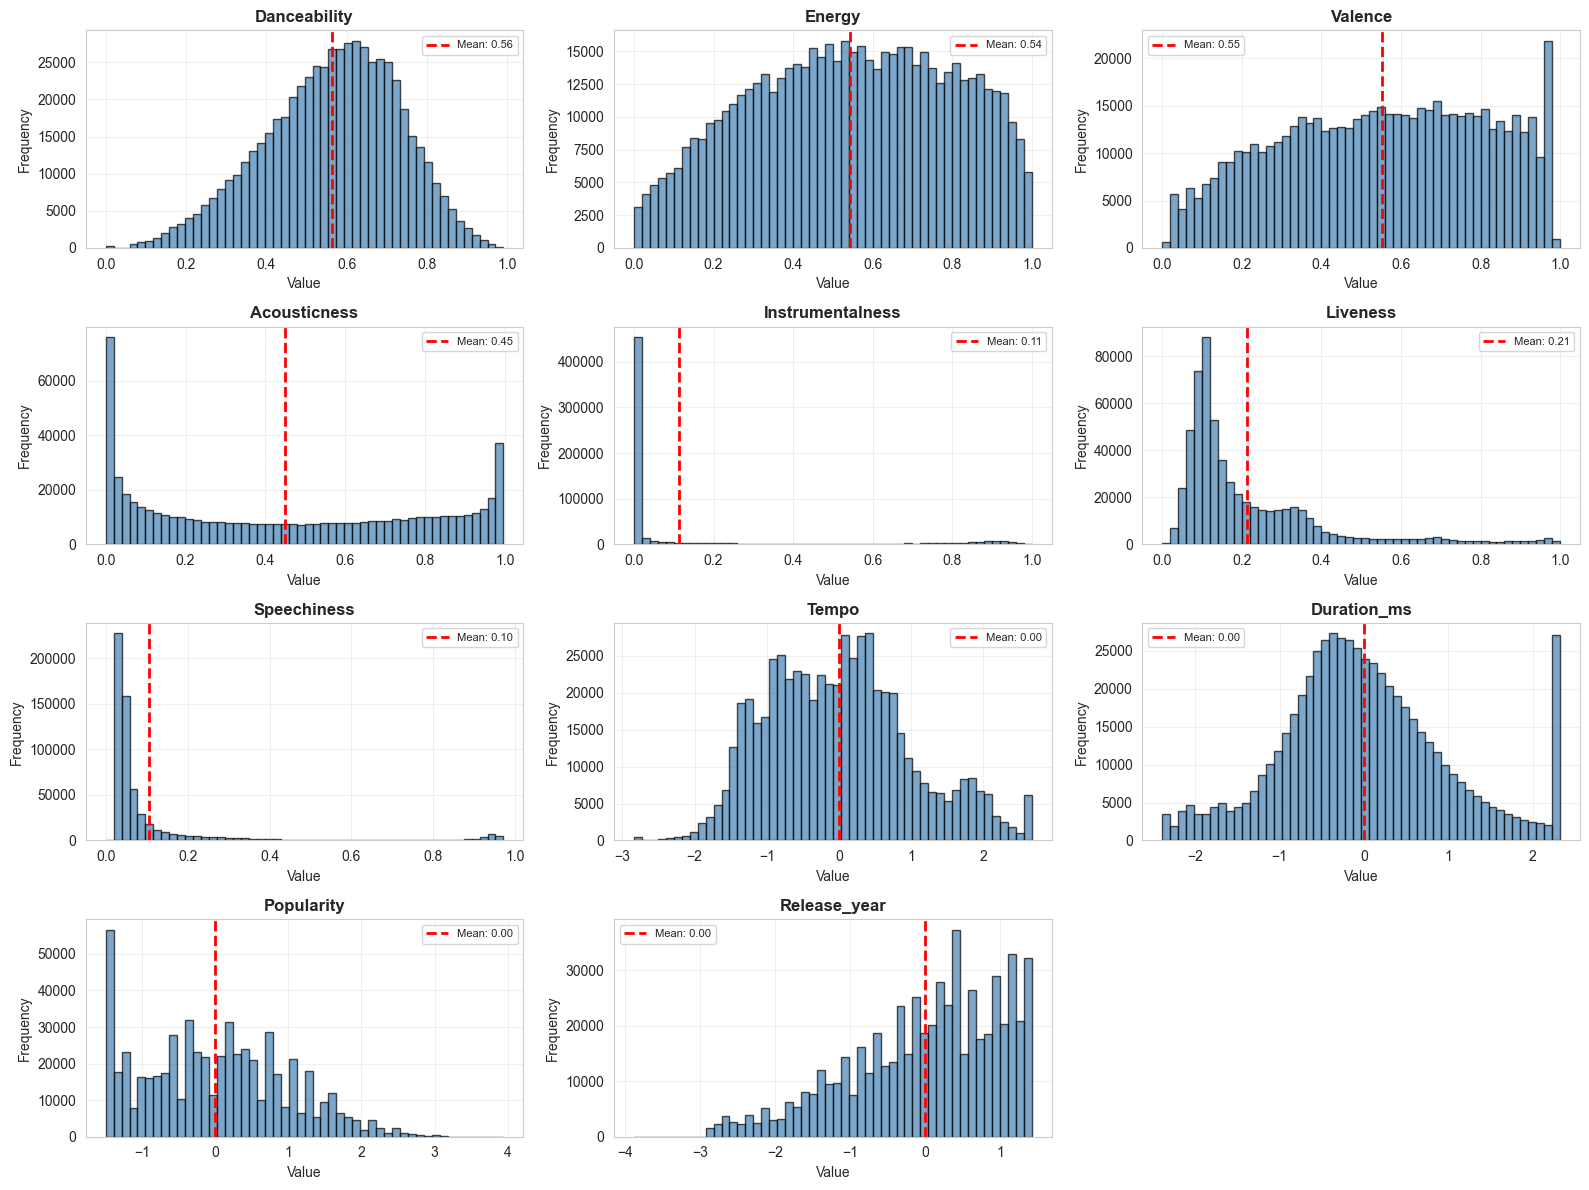


✓ Feature visualizations saved


In [9]:
# Statistics after preprocessing
print("="*80)
print("PREPROCESSED FEATURE STATISTICS")
print("="*80)

stats_df = pd.DataFrame({
    'Feature': recommendation_features,
    'Mean': X.mean(axis=0),
    'Std': X.std(axis=0),
    'Min': X.min(axis=0),
    'Max': X.max(axis=0),
    'Median': np.median(X, axis=0)
})

print(stats_df.to_string(index=False))

# Visualization: Feature distributions before and after
fig, axes = plt.subplots(4, 3, figsize=(16, 12))
axes = axes.ravel()

for idx, feat in enumerate(recommendation_features):
    ax = axes[idx]
    ax.hist(X[:, idx], bins=50, alpha=0.7, color='steelblue', edgecolor='black')
    ax.set_title(f'{feat.capitalize()}', fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.grid(True, alpha=0.3)
    ax.axvline(X[:, idx].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {X[:, idx].mean():.2f}')
    ax.legend(fontsize=8)

# Hide empty subplots
for idx in range(len(recommendation_features), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('../data/preprocessed_features.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Feature visualizations saved")

## Save Processed Data

In [10]:
# Save processed dataframe
output_path = Path('../data')
df_processed.to_csv(output_path / 'processed_spotify.csv', index=False)

# Save feature matrix as numpy
np.save(output_path / 'feature_matrix.npy', X)

# Save feature names (for later reference)
with open(output_path / 'feature_names.txt', 'w') as f:
    f.write('\n'.join(recommendation_features))

print("="*80)
print("PREPROCESSING COMPLETE")
print("="*80)
print(f"\nSaved files:")
print(f"  1. processed_spotify.csv - Full dataset with scaled features")
print(f"  2. feature_matrix.npy - Feature vectors (shape: {X.shape})")
print(f"  3. feature_names.txt - Feature names for reference")
print(f"\nReady for recommendation algorithm!")

✅ PREPROCESSING COMPLETE

Saved files:
  1. processed_spotify.csv - Full dataset with scaled features
  2. feature_matrix.npy - Feature vectors (shape: (586601, 11))
  3. feature_names.txt - Feature names for reference

Ready for recommendation algorithm!
